# Constrained Macro Scenario Optimisation

**Goal**: Find the *most plausible* deviation from the historical macro environment  
that causes the portfolio loss to exceed **10,000 EUR million**.

Formally:

$$\min_{\boldsymbol{\Delta} \in \mathbb{R}^6} \; D_M^2 = \boldsymbol{\Delta}^\top \boldsymbol{\Sigma}^{-1} \boldsymbol{\Delta}$$

$$\text{subject to} \quad L(\boldsymbol{\Delta}) \geq 10{,}000 \text{ EUR million}$$

where $\boldsymbol{\Delta} = \mathbf{x} - \boldsymbol{\mu}$ is the deviation of the macro scenario $\mathbf{x}$ from its  
historical mean $\boldsymbol{\mu}$, and $\boldsymbol{\Sigma}$ is the historical covariance matrix.

---

### Methodology

**Step 1 — Macro → stressed PD** (long-run sensitivity model):

From the OLS sensitivity analysis (current + 4 lagged macro factors), we compute the  
**cumulative impulse-response** beta for each variable by summing current and all lag coefficients.  
This represents the steady-state PD change after a *permanent* macro shift:

$$b_{s,j}^{\text{total}} = \sum_{k=0}^{4} \hat{\beta}_{s,j}^{(k)}$$

The stressed PD of exposure $i$ (in sector $s$) is then:

$$\text{PD}_i^*(\boldsymbol{\Delta}) = \sigma\!\left(\text{logit}(\text{PD}_i^0) + \mathbf{b}_{s(i)}^{\text{total}} \cdot \boldsymbol{\Delta}\right)$$

**Step 2 — Portfolio loss** (Gordy 2003 analytical approximation at 99.9%):

$$L(\boldsymbol{\Delta}) = \sum_{i=1}^{n} \text{EAD}_i \cdot \text{LGD} \cdot \Phi\!\left(\frac{\Phi^{-1}(\text{PD}_i^*) + \sqrt{\rho_i}\,\Phi^{-1}(q)}{\sqrt{1-\rho_i}}\right)$$

**Solver**: SLSQP (Sequential Least Squares Programming), scipy.optimize.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import norm, chi2
from scipy.optimize import minimize
import sys
import pathlib
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, str(pathlib.Path.cwd().parent))
from pd_pipeline.basel import asset_correlation_formula
from pd_pipeline import data, config

# ── Problem parameters ─────────────────────────────────────────────────────────
LGD             = 0.40
LOSS_QUANTILE   = 0.999       # Gordy tail quantile
LOSS_THRESHOLD  = 10_000.0    # EUR million
N_LAGS          = 4           # number of quarterly lags in the OLS

MACRO_VARS = ['GDP_Growth', 'Interest_Rate', 'Unemployment_Rate', 'Housing_Prices', 'CPI']
GPR_VARS   = ['GPR_Global']
ALL_VARS   = MACRO_VARS + GPR_VARS
N_VARS     = len(ALL_VARS)

VAR_LABELS = {
    'GDP_Growth'       : 'GDP Index',
    'Interest_Rate'    : 'Interest Rate (%)',
    'Unemployment_Rate': 'Unemployment Rate (%)',
    'Housing_Prices'   : 'Housing Price Index',
    'CPI'              : 'CPI Index',
    'GPR_Global'       : 'GPR Index',
}

print(f'LGD            = {LGD:.0%}')
print(f'Gordy quantile = {LOSS_QUANTILE:.1%}')
print(f'Loss threshold = {LOSS_THRESHOLD:,.0f} EUR million')

LGD            = 40%
Gordy quantile = 99.9%
Loss threshold = 10,000 EUR million


## 1. Portfolio Exposures

In [2]:
df_port = pd.read_csv('../data/portfolio_simulation.csv')
df_port['rho']        = df_port['pd'].apply(asset_correlation_formula)
df_port['pd_clipped'] = np.clip(df_port['pd'], 1e-9, 1 - 1e-9)

print(f'Exposures   : {len(df_port):,}')
print(f'Total EAD   : {df_port["ead_eur_m"].sum():,.1f} EUR million')
print(f'Average PD  : {df_port["pd"].mean()*100:.2f}%')
print()
print(df_port['sector'].value_counts().rename('count').to_frame().to_string())

Exposures   : 1,000
Total EAD   : 41,731.3 EUR million
Average PD  : 2.98%

                                      count
sector                                     
Finance, Insurance & Real Estate        271
Heavy Manufacturing                     143
Utilities                               120
Light Manufacturing                     112
Communications                          104
Mining & Construction                    74
Services                                 61
Wholesale & Retail Trade                 61
Transportation                           27
Health, Legal & Educational Services     19
Public Administration                     8


## 2. Long-Run Sensitivity Coefficients

The OLS regressions include the current period plus 4 lagged values of each macro variable.  
For a **permanent** macro shock $\Delta_j$, every lag also shifts by $\Delta_j$, so the  
long-run (steady-state) logit-PD response is the **sum of all coefficients** across lags.

In [3]:
df_sens = pd.read_csv('../01_pd_analysis/sensitivity_results_with_CI.csv')
df_s12  = df_sens[df_sens['PD_Horizon'] == '12_month'].copy()

# Sum current + lagged betas for each variable
sens_total = {}
for _, row in df_s12.iterrows():
    sector = row['Sector']
    betas = {}
    for v in MACRO_VARS:
        betas[v] = row[f'\u03b2_{v}'] + sum(
            row.get(f'\u03b2_{v}_lag{k}', 0) for k in range(1, N_LAGS + 1)
        )
    for v in GPR_VARS:
        betas[v] = row[f'\u03b4_{v}'] + sum(
            row.get(f'\u03b4_{v}_lag{k}', 0) for k in range(1, N_LAGS + 1)
        )
    sens_total[sector] = betas

# Print long-run sensitivity table
tbl = pd.DataFrame(sens_total).T[ALL_VARS].rename(columns=VAR_LABELS)
print('Long-run (summed) sensitivity coefficients  [Δ logit-PD per unit of Δ macro var]')
print(tbl.round(4).to_string())

Long-run (summed) sensitivity coefficients  [Δ logit-PD per unit of Δ macro var]
                                      GDP Index  Interest Rate (%)  Unemployment Rate (%)  Housing Price Index  CPI Index  GPR Index
Communications                          -0.0247            -0.2084                -0.3486              -0.0016     0.0860     0.0099
Utilities                               -0.0233            -0.1713                -0.3683              -0.0002     0.0380    -0.0039
Mining & Construction                   -0.2244            -1.3377                -1.0986              -0.0036     0.4083    -0.0062
Light Manufacturing                     -0.0431            -0.1213                -0.0121              -0.0003     0.0542    -0.0005
Heavy Manufacturing                     -0.0456            -0.5996                -0.3505              -0.0017     0.1499    -0.0151
Public Administration                    0.0359            -0.0925                -0.0660               0.0006    -0.0264

In [4]:
# Filter portfolio to sectors with sensitivities
df_valid = df_port[df_port['sector'].isin(sens_total)].copy().reset_index(drop=True)
print(f'Exposures matched to sensitivity sectors: {len(df_valid):,} / {len(df_port):,}')

n_exp = len(df_valid)
pd0   = df_valid['pd_clipped'].values
rho   = df_valid['rho'].values
ead   = df_valid['ead_eur_m'].values

# Build sensitivity matrix B_total : shape (n_exp, n_vars)
# Each row i contains the long-run beta vector for exposure i's sector
B_total = np.zeros((n_exp, N_VARS))
for i, (_, row) in enumerate(df_valid.iterrows()):
    s = row['sector']
    for j, v in enumerate(ALL_VARS):
        B_total[i, j] = sens_total[s][v]

# Pre-compute constants for the Gordy formula
sqrt_rho   = np.sqrt(rho)
sqrt_1mrho = np.sqrt(1 - rho)
inv_q      = norm.ppf(LOSS_QUANTILE)
logit_pd0  = np.log(pd0 / (1 - pd0))   # logit(PD_base)

Exposures matched to sensitivity sectors: 1,000 / 1,000


## 3. Historical Distribution Parameters

In [5]:
macro_frames = data.load_macro_data(
    gdp_path         = '../data/macro/global_gdp_monthly.csv',
    interest_path    = '../data/macro/intrest FRED.csv',
    unemployment_path= '../data/macro/sweden_unemployment_monthly.csv',
    housing_path     = '../data/macro/Bostadspriser ScB 1997-2025_transposed.csv',
    cpi_path         = '../data/macro/global_cpi_monthly.csv',
    verbose          = False,
)
df_gpr    = data.load_gpr_data('../data/geopolitical/data_gpr_Data_GPR.csv', verbose=False)
df_merged = data.merge_macro_data(macro_frames, df_gpr)

cov_df, _, mean_series = data.summarize_macro_data(
    df_merged, config.ALL_PREDICTOR_COLS, verbose=False
)

mu        = mean_series.values          # (6,)
Sigma     = cov_df.values               # (6×6)
Sigma_inv = np.linalg.inv(Sigma)
stds      = np.sqrt(np.diag(Sigma))

print('Historical mean vector μ  (= scenario baseline):')
for v, m, s in zip(ALL_VARS, mu, stds):
    print(f'  {v:30s}: μ = {m:>10.3f},  σ = {s:>8.3f}')

Historical mean vector μ  (= scenario baseline):
  GDP_Growth                    : μ =    110.933,  σ =   13.041
  Interest_Rate                 : μ =      4.602,  σ =    3.539
  Unemployment_Rate             : μ =      6.584,  σ =    2.373
  Housing_Prices                : μ =   2214.650,  σ = 1010.109
  CPI                           : μ =    108.501,  σ =   19.918
  GPR_Global                    : μ =    103.003,  σ =   47.591


## 4. Loss Function and Baseline

The loss function maps a **deviation vector** $\boldsymbol{\Delta}$ from the historical mean  
to the Gordy 99.9% portfolio loss.  At $\boldsymbol{\Delta} = \mathbf{0}$ the portfolio uses its  
base PDs (no macro stress).

In [6]:
def portfolio_loss(delta: np.ndarray) -> float:
    """Gordy 99.9% portfolio loss (EUR million) under macro deviation Δ from μ."""
    adj        = np.clip(B_total @ delta, -50, 50)
    logit_pd_s = logit_pd0 + adj
    pd_s       = 1 / (1 + np.exp(-logit_pd_s))
    pd_s       = np.clip(pd_s, 1e-9, 1 - 1e-9)
    inv_pd_s   = norm.ppf(pd_s)
    cond_pd    = norm.cdf((inv_pd_s + sqrt_rho * inv_q) / sqrt_1mrho)
    return float(np.sum(ead * LGD * cond_pd))


def mahal_sq(delta: np.ndarray) -> float:
    """Squared Mahalanobis distance of Δ."""
    return float(delta @ Sigma_inv @ delta)


def mahal_sq_grad(delta: np.ndarray) -> np.ndarray:
    """Analytical gradient of the squared Mahalanobis distance."""
    return 2 * Sigma_inv @ delta


# Baseline (no stress)
loss_base = portfolio_loss(np.zeros(N_VARS))
print(f'Baseline loss (Δ = 0, q = 99.9%): {loss_base:>8,.0f} EUR million')
print(f'Loss threshold                   : {LOSS_THRESHOLD:>8,.0f} EUR million')
print(f'Required stress increase         : {LOSS_THRESHOLD - loss_base:>8,.0f} EUR million  '
      f'(+{(LOSS_THRESHOLD/loss_base - 1)*100:.0f}%)')

Baseline loss (Δ = 0, q = 99.9%):    2,410 EUR million
Loss threshold                   :   10,000 EUR million
Required stress increase         :    7,590 EUR million  (+315%)


## 5. Loss Surface — Single-Factor Sensitivity

Each panel shows how the portfolio loss responds to a ±3σ shift in one macro  
variable while all others remain at their historical mean.

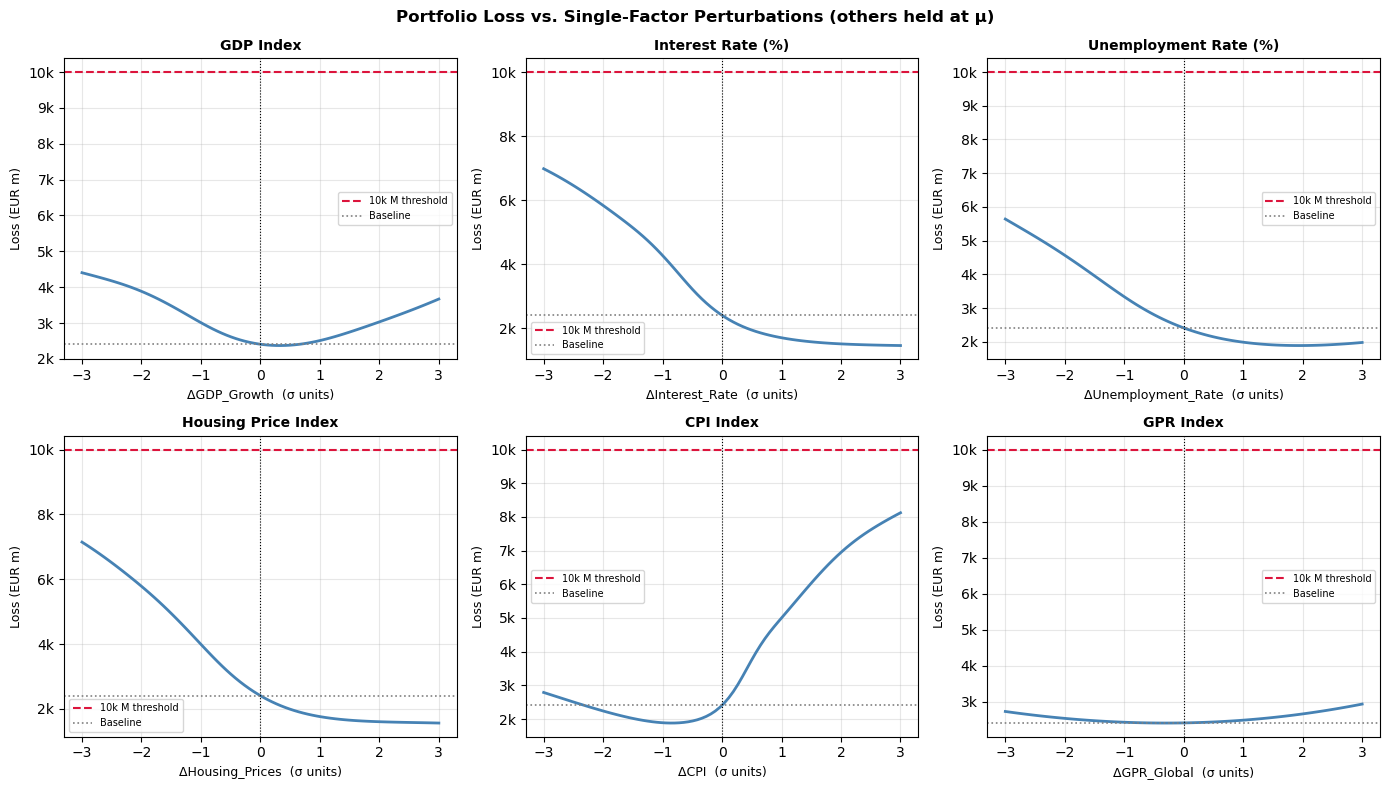

Chart saved → constrained_opt_loss_surface.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = axes.flatten()

for idx, var in enumerate(ALL_VARS):
    ax  = axes_flat[idx]
    j   = ALL_VARS.index(var)
    std = stds[j]

    sweep  = np.linspace(-3 * std, 3 * std, 80)
    losses = []
    for dev in sweep:
        delta_test      = np.zeros(N_VARS)
        delta_test[j]   = dev
        losses.append(portfolio_loss(delta_test))

    ax.plot(sweep / std, losses, lw=2, color='steelblue')
    ax.axhline(LOSS_THRESHOLD, color='crimson', ls='--', lw=1.5,
               label=f'{LOSS_THRESHOLD/1000:.0f}k M threshold')
    ax.axhline(loss_base, color='grey', ls=':', lw=1.2, label='Baseline')
    ax.axvline(0, color='black', lw=0.8, ls=':')
    ax.set_xlabel(f'Δ{var}  (σ units)', fontsize=9)
    ax.set_ylabel('Loss (EUR m)', fontsize=9)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
    ax.set_title(VAR_LABELS[var], fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig.suptitle('Portfolio Loss vs. Single-Factor Perturbations (others held at μ)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('constrained_opt_loss_surface.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → constrained_opt_loss_surface.png')

## 6. Constrained Optimisation

We minimise the **squared Mahalanobis distance** of $\boldsymbol{\Delta}$ from zero  
(equivalently, the deviation from the historical mean) subject to the loss constraint.

Three starting points are used for robustness.

In [8]:
constraint = {
    'type': 'ineq',
    'fun' : lambda delta: portfolio_loss(delta) - LOSS_THRESHOLD,
}

# Starting points: zero (no stress), and two pre-stressed directions
delta0_list = [
    np.zeros(N_VARS),
    np.array([-1.5, +1.0, +2.0, -0.5, +0.5, +1.0]) * stds,
    np.array([-1.0, +2.0, +2.5, -1.0, +1.5, +0.5]) * stds,
]

best = None
for k, d0 in enumerate(delta0_list):
    res = minimize(
        mahal_sq,
        d0,
        method      = 'SLSQP',
        jac         = mahal_sq_grad,
        constraints = constraint,
        options     = dict(maxiter=3000, ftol=1e-12),
    )
    L     = portfolio_loss(res.x)
    D     = np.sqrt(mahal_sq(res.x))
    ok    = L >= LOSS_THRESHOLD - 1.0
    print(f'Run {k+1}: success={res.success}, feasible={ok}, '
          f'D_M={D:.4f},  loss={L:,.0f} EUR m')
    if ok and (best is None or res.fun < best.fun):
        best = res

assert best is not None, 'No feasible solution found'
delta_opt = best.x
D_opt     = np.sqrt(mahal_sq(delta_opt))
L_opt     = portfolio_loss(delta_opt)
x_opt     = mu + delta_opt

print(f'\n✓ Optimal Δ*:  D_M = {D_opt:.4f},  Loss = {L_opt:,.1f} EUR million')

Run 1: success=True, feasible=True, D_M=7.4101,  loss=10,000 EUR m


Run 2: success=True, feasible=True, D_M=7.4101,  loss=10,000 EUR m


Run 3: success=True, feasible=True, D_M=7.4101,  loss=10,000 EUR m

✓ Optimal Δ*:  D_M = 7.4101,  Loss = 10,000.0 EUR million


## 7. Optimal Scenario — Results Table

In [9]:
deviations_sigma = delta_opt / stds

results_df = pd.DataFrame({
    'Variable'          : ALL_VARS,
    'Label'             : [VAR_LABELS[v] for v in ALL_VARS],
    'Hist. mean μ'      : mu,
    'Optimal x* = μ+Δ*' : x_opt,
    'Δ* (raw)'          : delta_opt,
    'Δ* / σ'            : deviations_sigma,
})

print('=' * 90)
print('OPTIMAL MACRO SCENARIO  —  most plausible scenario with portfolio loss ≥ 10,000 EUR m')
print('=' * 90)
print(results_df.to_string(index=False,
                            float_format=lambda v: f'{v:>10.3f}'))

p_chi2  = chi2.cdf(D_opt**2, df=N_VARS)
p_excl  = 1 - p_chi2

print()
print(f'Mahalanobis distance D_M*        = {D_opt:.4f}')
print(f'Squared D_M*  (=  χ² statistic)  = {D_opt**2:.4f}')
print(f'χ²({N_VARS}) tail probability      = {p_excl:.4f}  '
      f'(under MVN, {p_excl*100:.2f}% of macro draws are at least this extreme)')
print()
print(f'Portfolio loss at Δ* (optimum)   = {L_opt:>10,.1f} EUR million')
print(f'Portfolio loss at Δ=0 (baseline) = {loss_base:>10,.1f} EUR million')
print(f'Stress increase                  = {L_opt - loss_base:>10,.1f} EUR million  '
      f'(+{(L_opt/loss_base - 1)*100:.1f}%)')

OPTIMAL MACRO SCENARIO  —  most plausible scenario with portfolio loss ≥ 10,000 EUR m
         Variable                 Label  Hist. mean μ  Optimal x* = μ+Δ*   Δ* (raw)     Δ* / σ
       GDP_Growth             GDP Index       110.933            152.044     41.111      3.152
    Interest_Rate     Interest Rate (%)         4.602              0.669     -3.933     -1.111
Unemployment_Rate Unemployment Rate (%)         6.584             12.313      5.729      2.414
   Housing_Prices   Housing Price Index      2214.650           1581.548   -633.103     -0.627
              CPI             CPI Index       108.501            165.350     56.850      2.854
       GPR_Global             GPR Index       103.003            356.587    253.585      5.328

Mahalanobis distance D_M*        = 7.4101
Squared D_M*  (=  χ² statistic)  = 54.9089
χ²(6) tail probability      = 0.0000  (under MVN, 0.00% of macro draws are at least this extreme)

Portfolio loss at Δ* (optimum)   =   10,000.0 EUR million
Portfo

## 8. Stressed PDs at the Optimal Scenario

In [10]:
adj_opt     = np.clip(B_total @ delta_opt, -50, 50)
pd_stressed = 1 / (1 + np.exp(-(logit_pd0 + adj_opt)))
pd_stressed = np.clip(pd_stressed, 1e-9, 1 - 1e-9)

df_valid = df_valid.copy()
df_valid['pd_base']     = pd0
df_valid['pd_stressed'] = pd_stressed
df_valid['pd_mult']     = pd_stressed / pd0

tbl_pd = (
    df_valid.groupby('sector')
    .agg(
        n              = ('pd_base', 'count'),
        pd_base_pct    = ('pd_base',     lambda x: f"{x.mean()*100:.2f}%"),
        pd_stress_pct  = ('pd_stressed', lambda x: f"{x.mean()*100:.2f}%"),
        stress_mult    = ('pd_mult',     lambda x: f"{x.mean():.2f}×"),
    )
)
print('Stressed PD summary by sector at optimal Δ*:')
print(tbl_pd.to_string())
print()
print(f'Portfolio-wide base PD    : {pd0.mean()*100:.2f}%')
print(f'Portfolio-wide stressed PD: {pd_stressed.mean()*100:.2f}%')
print(f'Average stress multiplier : {(pd_stressed / pd0).mean():.2f}×')

Stressed PD summary by sector at optimal Δ*:
                                        n pd_base_pct pd_stress_pct stress_mult
sector                                                                         
Communications                        104       1.94%        61.81%     192.24×
Finance, Insurance & Real Estate      271       2.30%        28.92%      50.04×
Health, Legal & Educational Services   19       3.16%        68.31%     243.30×
Heavy Manufacturing                   143       3.48%        34.01%      46.88×
Light Manufacturing                   112       4.01%        13.27%       5.39×
Mining & Construction                  74       3.02%        99.95%     430.89×
Public Administration                   8       3.89%         0.74%       0.17×
Services                               61       2.60%        70.88%     211.61×
Transportation                         27       3.09%        35.08%      65.80×
Utilities                             120       3.55%         1.84%       0

## 9. Visualisation

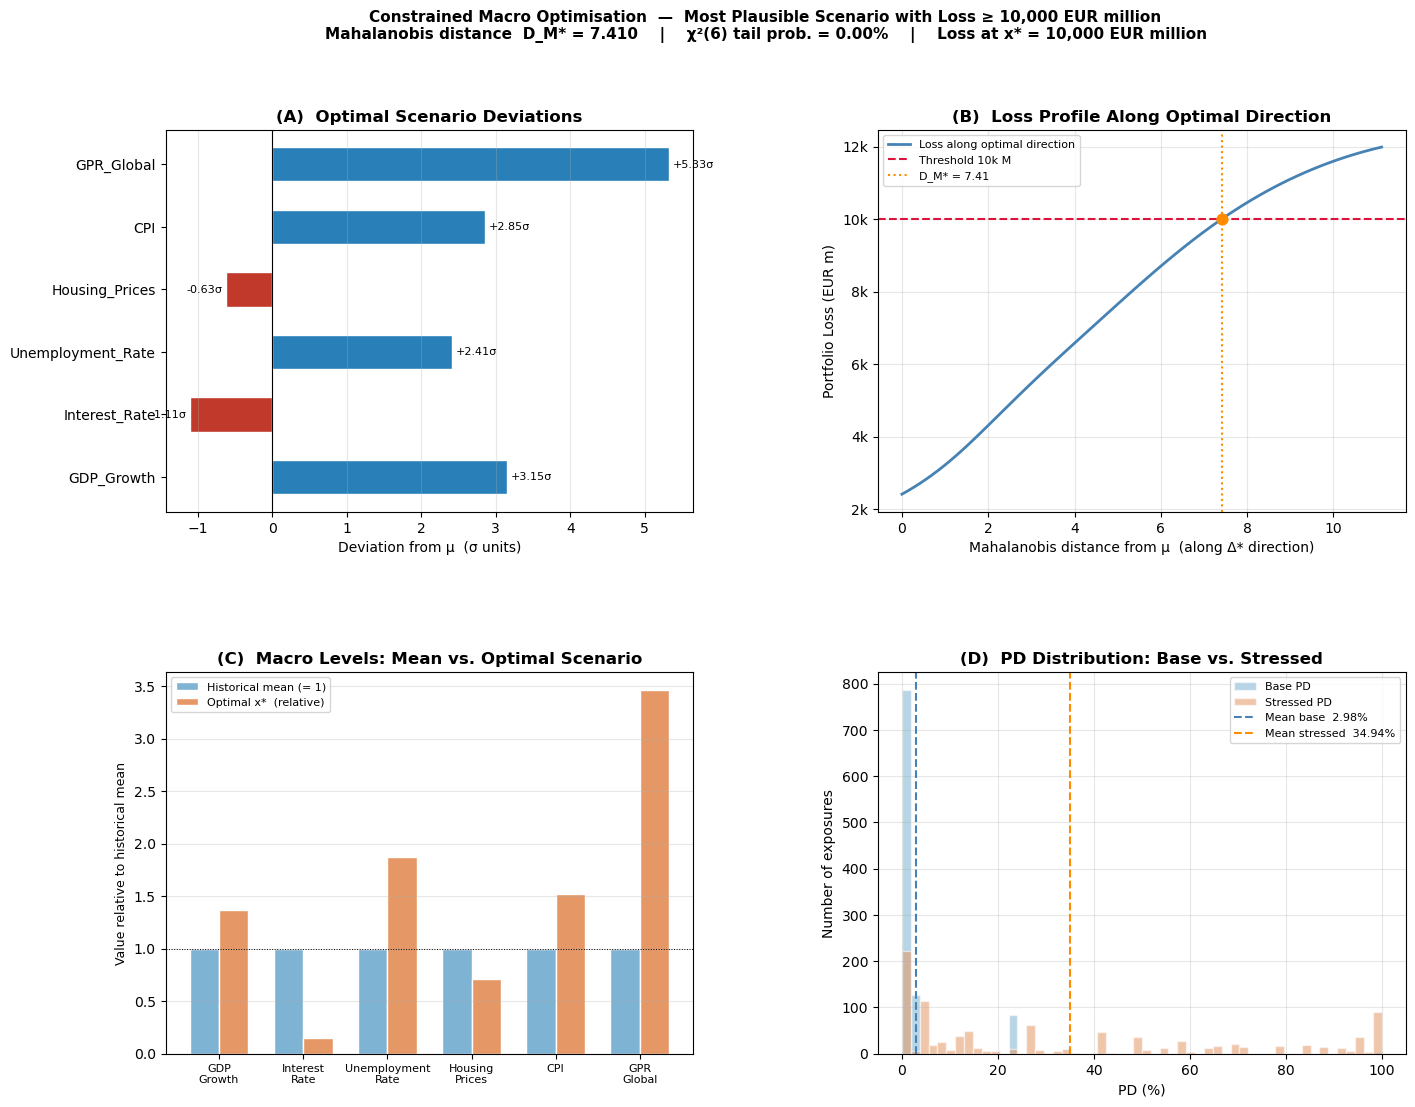

Chart saved → constrained_opt_results.png


In [11]:
fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.35)

# ── A: Scenario deviations (bar chart, σ units) ───────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
colors_a = ['#c0392b' if d < 0 else '#2980b9' for d in deviations_sigma]
bars = ax_a.barh(ALL_VARS, deviations_sigma, color=colors_a, edgecolor='white', height=0.55)
ax_a.axvline(0, color='black', lw=0.8)
for bar, val in zip(bars, deviations_sigma):
    ha = 'left' if val >= 0 else 'right'
    ax_a.text(val + (0.05 if val >= 0 else -0.05),
              bar.get_y() + bar.get_height() / 2,
              f'{val:+.2f}σ', va='center', ha=ha, fontsize=8)
ax_a.set_xlabel('Deviation from μ  (σ units)', fontsize=10)
ax_a.set_title('(A)  Optimal Scenario Deviations', fontweight='bold')
ax_a.grid(axis='x', alpha=0.3)

# ── B: Loss profile along the optimal direction ───────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
direction   = delta_opt / (D_opt + 1e-12)
alphas      = np.linspace(0, D_opt * 1.5, 80)
loss_profile= [portfolio_loss(a * direction) for a in alphas]

ax_b.plot(alphas, loss_profile, lw=2, color='steelblue', label='Loss along optimal direction')
ax_b.axhline(LOSS_THRESHOLD, color='crimson', ls='--', lw=1.5,
             label=f'Threshold {LOSS_THRESHOLD/1000:.0f}k M')
ax_b.axvline(D_opt, color='darkorange', ls=':', lw=1.5,
             label=f'D_M* = {D_opt:.2f}')
ax_b.scatter([D_opt], [L_opt], color='darkorange', zorder=5, s=60)
ax_b.set_xlabel('Mahalanobis distance from μ  (along Δ* direction)', fontsize=10)
ax_b.set_ylabel('Portfolio Loss (EUR m)', fontsize=10)
ax_b.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
ax_b.set_title('(B)  Loss Profile Along Optimal Direction', fontweight='bold')
ax_b.legend(fontsize=8)
ax_b.grid(alpha=0.3)

# ── C: Absolute macro levels: mean vs optimal ─────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
x_pos  = np.arange(N_VARS)
width  = 0.35
ratio  = x_opt / mu
ax_c.bar(x_pos - width/2, np.ones(N_VARS), width, label='Historical mean (= 1)', color='#7fb3d3', edgecolor='white')
ax_c.bar(x_pos + width/2, ratio,            width, label='Optimal x*  (relative)', color='#e59866', edgecolor='white')
ax_c.axhline(1.0, color='black', lw=0.7, ls=':')
ax_c.set_xticks(x_pos)
ax_c.set_xticklabels([v.replace('_', '\n') for v in ALL_VARS], fontsize=8)
ax_c.set_ylabel('Value relative to historical mean', fontsize=9)
ax_c.set_title('(C)  Macro Levels: Mean vs. Optimal Scenario', fontweight='bold')
ax_c.legend(fontsize=8)
ax_c.grid(axis='y', alpha=0.3)

# ── D: PD distribution base vs stressed ───────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
pd_max_pct = min(max(pd_stressed.max(), pd0.max()) * 100 * 1.1, 100)
bins = np.linspace(0, pd_max_pct, 55)
ax_d.hist(pd0       * 100, bins=bins, alpha=0.55, label='Base PD',     color='#7fb3d3', edgecolor='white')
ax_d.hist(pd_stressed * 100, bins=bins, alpha=0.55, label='Stressed PD', color='#e59866', edgecolor='white')
ax_d.axvline(pd0.mean()        * 100, color='steelblue', ls='--', lw=1.5,
             label=f'Mean base  {pd0.mean()*100:.2f}%')
ax_d.axvline(pd_stressed.mean() * 100, color='darkorange', ls='--', lw=1.5,
             label=f'Mean stressed  {pd_stressed.mean()*100:.2f}%')
ax_d.set_xlabel('PD (%)', fontsize=10)
ax_d.set_ylabel('Number of exposures', fontsize=10)
ax_d.set_title('(D)  PD Distribution: Base vs. Stressed', fontweight='bold')
ax_d.legend(fontsize=8)
ax_d.grid(alpha=0.3)

fig.suptitle(
    f'Constrained Macro Optimisation  —  Most Plausible Scenario with Loss ≥ {LOSS_THRESHOLD:,.0f} EUR million\n'
    f'Mahalanobis distance  D_M* = {D_opt:.3f}    |    '
    f'χ²({N_VARS}) tail prob. = {p_excl*100:.2f}%    |    '
    f'Loss at x* = {L_opt:,.0f} EUR million',
    fontsize=11, fontweight='bold',
)
plt.savefig('constrained_opt_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → constrained_opt_results.png')

## 10. Pareto Frontier — Plausibility vs. Severity

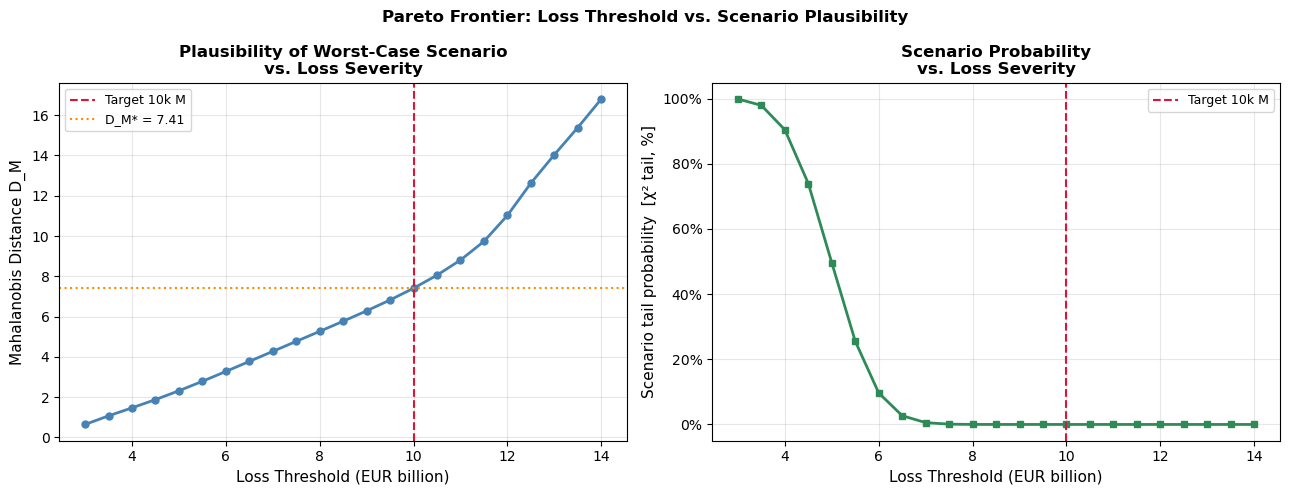

Chart saved → constrained_opt_frontier.png


In [12]:
thresholds  = np.arange(3_000, 14_001, 500, dtype=float)
front_D     = []
front_L     = []
front_ok    = []
delta_warm  = np.zeros(N_VARS)

for thr in thresholds:
    con = {'type': 'ineq', 'fun': lambda d, t=thr: portfolio_loss(d) - t}
    res = minimize(mahal_sq, delta_warm, method='SLSQP',
                   jac=mahal_sq_grad, constraints=con,
                   options=dict(maxiter=3000, ftol=1e-12))
    L   = portfolio_loss(res.x)
    D   = np.sqrt(mahal_sq(res.x))
    ok  = L >= thr - 5.0
    front_D.append(D)
    front_L.append(L)
    front_ok.append(ok)
    if ok:
        delta_warm = res.x

ok_idx   = np.where(front_ok)[0]
thr_ok   = thresholds[ok_idx] / 1000
D_ok     = np.array(front_D)[ok_idx]
p_ok     = (1 - chi2.cdf(D_ok**2, df=N_VARS)) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(thr_ok, D_ok, 'o-', color='steelblue', lw=2, ms=5)
ax1.axvline(LOSS_THRESHOLD / 1000, color='crimson', ls='--', lw=1.5,
            label=f'Target {LOSS_THRESHOLD/1000:.0f}k M')
ax1.axhline(D_opt, color='darkorange', ls=':', lw=1.5, label=f'D_M* = {D_opt:.2f}')
ax1.set_xlabel('Loss Threshold (EUR billion)', fontsize=11)
ax1.set_ylabel('Mahalanobis Distance D_M', fontsize=11)
ax1.set_title('Plausibility of Worst-Case Scenario\nvs. Loss Severity', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.plot(thr_ok, p_ok, 's-', color='seagreen', lw=2, ms=5)
ax2.axvline(LOSS_THRESHOLD / 1000, color='crimson', ls='--', lw=1.5,
            label=f'Target {LOSS_THRESHOLD/1000:.0f}k M')
ax2.set_xlabel('Loss Threshold (EUR billion)', fontsize=11)
ax2.set_ylabel('Scenario tail probability  [χ² tail, %]', fontsize=11)
ax2.set_title('Scenario Probability\nvs. Loss Severity', fontweight='bold')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

fig.suptitle('Pareto Frontier: Loss Threshold vs. Scenario Plausibility',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('constrained_opt_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → constrained_opt_frontier.png')

## Summary

| | |
|---|---|
| **Loss threshold** | 10,000 EUR million |
| **Baseline loss** (no macro stress, q = 99.9%) | 2,410 EUR million |
| **Optimal Mahalanobis distance** D_M* | see cell above |
| **Scenario probability** (χ²(6) tail) | see cell above |
| **Gordy quantile** | 99.9% |
| **LGD** | 40% |

### Key design choices

1. **Long-run sensitivities**: Summing current + 4 lagged beta coefficients gives the  
   steady-state PD response to a permanent macro shock — more meaningful for scenario analysis  
   than using only the current-period coefficient in a multicollinear lag regression.

2. **Deviation formulation**: The optimization is over $\boldsymbol{\Delta} = \mathbf{x} - \boldsymbol{\mu}$,  
   so at $\boldsymbol{\Delta} = 0$ the portfolio uses its base PDs and the loss is the Gordy VaR  
   at the historical macro average — a natural anchor point.

3. **Mahalanobis plausibility**: Under a multivariate-normal approximation of the macro distribution,  
   the χ²(6) tail probability gives the fraction of historical macro observations that would be  
   at least as extreme as the optimal stress scenario.

4. **Pareto frontier** (section 10): Sweeping the loss threshold from 3,000 to 14,000 EUR million  
   traces the full trade-off between scenario plausibility and loss severity.